# First-Pass Data Exploration

This notebook is the readable companion to `2_data/scripts/data_exploration.py`.

The script contains reusable download, metadata parsing, and coverage logic. This notebook explains why each step is useful, calls that logic, and displays the main results for local inspection.


## Research Motivation

Before building a modeling panel, we need to know whether the candidate target and predictors are feasible.

The key questions are:

1. Which OECD environment-related patent indicators exist in the relevant dataflow?
2. How do broad target candidates such as `PT_TECH.DEV.ENV_PAT._Z`, `PT_INV.DEV.ENV_PAT._Z`, and `INV_PS.DEV.ENV_PAT._Z` emerge from the OECD indicator dimensions?
3. Which technology domains sit below the broad `ENV_PAT` environment-related total?
4. Which candidate predictors have enough country-year coverage?
5. Which choices should remain deferred until the literature and metadata are checked?


## Optional Google Colab Setup

Run the next cell only when opening this notebook in Google Colab. It clones the repository, switches the working directory to the project root, and installs the project dependencies. In local Jupyter, the cell detects that it is not in Colab and safely skips itself.

If the repository is private, create a Colab secret named `GITHUB_TOKEN` with read access to this repository and enable notebook access for that secret before running the setup cell.


In [1]:
# Optional: run this cell only when using Google Colab.
import importlib.util
import os
import stat
import subprocess
import sys
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None
REPO_URL = "https://github.com/songjie1025/env-innovation-prediction.git"
REPO_DIR = Path("/content/env-innovation-prediction")
TOKEN_SECRET_NAME = "GITHUB_TOKEN"


def get_colab_secret(name):
    try:
        from google.colab import userdata

        return userdata.get(name)
    except Exception:
        return None


def git_environment(token):
    env = os.environ.copy()
    env["GIT_TERMINAL_PROMPT"] = "0"
    if token:
        askpass_path = Path("/content/git_askpass.py")
        askpass_path.write_text(
            "import os, sys\n"
            "prompt = sys.argv[1].lower() if len(sys.argv) > 1 else ''\n"
            "print('x-access-token' if 'username' in prompt else os.environ['GITHUB_TOKEN'])\n",
            encoding="utf-8",
        )
        askpass_path.chmod(stat.S_IRUSR | stat.S_IWUSR | stat.S_IXUSR)
        env["GIT_ASKPASS"] = str(askpass_path)
        env["GITHUB_TOKEN"] = token
    return env


def run_checked(command, env=None):
    result = subprocess.run(command, check=False, text=True, capture_output=True, env=env)
    if result.returncode != 0:
        message = result.stderr.strip() or result.stdout.strip()
        raise RuntimeError(message)
    return result

if IN_COLAB:
    token = get_colab_secret(TOKEN_SECRET_NAME)
    git_env = git_environment(token)
    try:
        if not REPO_DIR.exists():
            run_checked(["git", "clone", REPO_URL, str(REPO_DIR)], env=git_env)
        else:
            run_checked(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], env=git_env)
    except RuntimeError as exc:
        if not token:
            raise RuntimeError(
                "Could not clone or update the repository. If it is private, add a Colab "
                "secret named GITHUB_TOKEN with repository read access and enable notebook access."
            ) from exc
        raise RuntimeError(
            "Could not clone or update the repository with GITHUB_TOKEN. Check that the token "
            "has repository read access and that notebook access is enabled for the secret."
        ) from exc

    os.chdir(REPO_DIR)
    run_checked([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
    print(f"Colab setup complete. Current directory: {Path.cwd()}")
else:
    print("Not running in Google Colab; skipping optional Colab setup.")


Not running in Google Colab; skipping optional Colab setup.


In [2]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]

SCRIPT_DIR = ROOT / "2_data" / "scripts"
PROCESSED_DIR = ROOT / "2_data" / "processed"

sys.path.append(str(SCRIPT_DIR))

from data_exploration import run_exploration

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 110)


/Users/marcjin/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/ww/t65x1vvn57150sj48rpvwl880000gn/T/matplotlib-fdocdpjr because there was an issue with the default path (/Users/marcjin/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/marcjin/.cache/fontconfig
	/Users/marcjin/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/marcjin/.cache/fontconfig
	/Users/marcjin/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/marcjin/.cache/fontconfig
	/Users/marcjin/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/marcjin/.cache/fontconfig
	/Users/marcjin/.fontconfig


Matplotlib is building the font cache; this may take a moment.


## Load or Regenerate Exploration Outputs

By default, the notebook reads the committed processed outputs from `2_data/processed/`.

Set `RUN_DOWNLOADS = True` only when you want to refresh the raw downloads, OECD metadata, and processed summaries. Raw files are stored in `2_data/raw/` and are ignored by Git.


In [3]:
RUN_DOWNLOADS = False
START_YEAR = 1990
END_YEAR = 2024

required_outputs = {
    "summary": PROCESSED_DIR / "data_availability.csv",
    "dimension_values": PROCESSED_DIR / "oecd_patent_dimension_values.csv",
    "target_candidate_catalog": PROCESSED_DIR / "oecd_patent_target_candidates.csv",
    "technology_domains": PROCESSED_DIR / "oecd_patent_technology_domains.csv",
    "technology_category_summary": PROCESSED_DIR / "oecd_patent_technology_category_summary.csv",
}

if RUN_DOWNLOADS or not all(path.exists() for path in required_outputs.values()):
    summary = run_exploration(start_year=START_YEAR, end_year=END_YEAR)
else:
    summary = pd.read_csv(required_outputs["summary"])

dimension_values = pd.read_csv(required_outputs["dimension_values"])
target_candidate_catalog = pd.read_csv(required_outputs["target_candidate_catalog"])
technology_domains = pd.read_csv(required_outputs["technology_domains"])
technology_category_summary = pd.read_csv(required_outputs["technology_category_summary"])

summary


,dataset_id,variable,source_variable,total_rows,non_missing_observations,missing_observations,countries_total,countries_with_data,years_total,years_with_data,first_year,last_year
0,oecd_eps,eps_index,POL_STRINGENCY.EPS,1240,1240,0,40,40,31,31,1990,2020
1,oecd_patents_environment,env_patent_share_inventions,PT_INV.DEV.ENV_PAT._Z,3538,3538,0,202,202,34,34,1990,2023
2,oecd_patents_environment,env_patent_share_tech,PT_TECH.DEV.ENV_PAT._Z,3538,3538,0,202,202,34,34,1990,2023
3,oecd_patents_environment,env_patents_per_million,INV_PS.DEV.ENV_PAT._Z,3528,3528,0,196,196,34,34,1990,2023
4,world_bank_wdi,co2_per_capita,EN.ATM.CO2E.PC,6562,5920,642,193,191,34,31,1990,2020
5,world_bank_wdi,energy_intensity,EG.EGY.PRIM.PP.KD,7595,4486,3109,217,201,35,23,2000,2022
6,world_bank_wdi,fossil_energy_share,EG.USE.COMM.FO.ZS,7595,4978,2617,217,179,35,35,1990,2024
7,world_bank_wdi,gdp,NY.GDP.MKTP.KD,7595,7096,499,217,213,35,35,1990,2024
8,world_bank_wdi,gdp_per_capita,NY.GDP.PCAP.KD,7595,7096,499,217,213,35,35,1990,2024
9,world_bank_wdi,manufacturing_share,NV.IND.MANF.ZS,7595,6000,1595,217,203,35,35,1990,2024


## How the OECD Indicator Space Is Structured

The relevant OECD dataflow is `Patents - indicators`. A source variable in this project is a combination of four analytical dimensions:

```text
UNIT_MEASURE.TYPE.TECH.PAT
```

For example, `PT_INV.DEV.ENV_PAT._Z` means:

1. `PT_INV`: percentage of inventions.
2. `DEV`: development of environment-related technologies.
3. `ENV_PAT`: environment-related technologies as the broad technology domain.
4. `_Z`: no regional patent-office breakdown.

This structure is why the target choice should not be made from one code alone. We first need to understand the available measure, counting type, technology-domain, and patent-office options.


In [4]:
for dimension in ["UNIT_MEASURE", "TYPE", "TECH", "PAT"]:
    display(
        dimension_values.loc[dimension_values["dimension"].eq(dimension), ["code", "label"]]
        .reset_index(drop=True)
        .style.set_caption(f"OECD dimension: {dimension}")
    )


,code,label
0,INV_PS,Inventions per person
1,INV_RD_S13,Inventions per unit of government R&D
2,INV_RD_S1ZS,Inventions per unit of public R&D
3,IX,Index
4,PT_INV,Percentage of inventions
5,PT_TECH,Percentage of technologies
6,PT_TECH_COL,Percentage of collaborations in all technologies
7,PT_TECH_ENV,Percentage of environment related technologies


,code,label
0,COL,International collaboration in development of environment-related technologies
1,DEV,Development of environment-related technologies
2,DIFF,Diffusion of environment-related technologies
3,RENEW,Development of renewable energy technologies


,code,label
0,ADAPT,Climate change adaptation technologies
1,BUILD,Climate change mitigation technologies related to buildings
2,ENE,"Climate change mitigation technologies related to energy generation, transmission or distribution"
3,ENV_PAT,Environment-related technologies
4,GHG,"Capture, storage, sequestration or disposal of greenhouse gases"
5,GOODS,Climate change mitigation technologies in the production or processing of goods
6,ICT,Climate change mitigation in information and communication technologies (ICT)
7,MAN,Environmental management
8,OCEAN,Sustainable ocean economy
9,TOT,All technologies (total patents)


,code,label
0,_Z,Not applicable
1,ARIPO,African Regional Industrial Property Organisation
2,EAPO,Eurasian Patent Organization
3,EPO,European Patent Office
4,GCC,Patent Office of the Cooperation Council for the Arab States of the Gulf
5,OAPI,African Intellectual Property Organization
6,PCT,Patent Cooperation Treaty


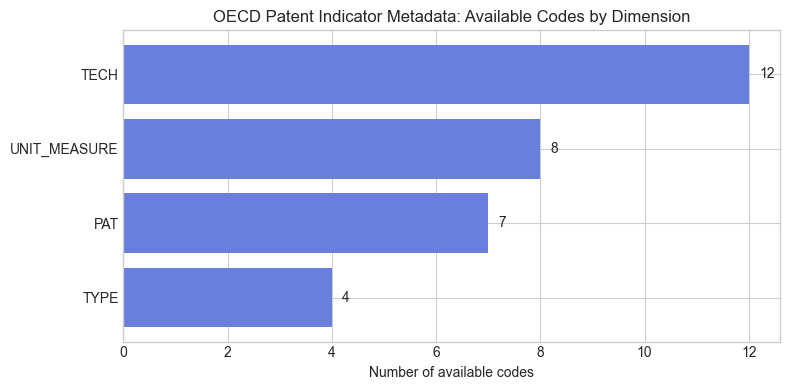

In [5]:
dimension_counts = (
    dimension_values.groupby(["dimension", "dimension_label"], as_index=False)
    .size()
    .rename(columns={"size": "available_codes"})
    .sort_values("available_codes")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(dimension_counts["dimension"], dimension_counts["available_codes"], color="#6A7FDB")
ax.set_title("OECD Patent Indicator Metadata: Available Codes by Dimension")
ax.set_xlabel("Number of available codes")
ax.set_ylabel("")
for i, value in enumerate(dimension_counts["available_codes"]):
    ax.text(value + 0.2, i, str(value), va="center")
plt.tight_layout()


## Broad Target Candidates

The three current target candidates are broad because they all use `TECH = ENV_PAT`, the OECD total for environment-related technologies. They differ in measurement scale, not in environmental subfield.

The final target is still deferred. This table is meant to make the candidate construction transparent for team discussion.


In [6]:
target_coverage = summary[summary["dataset_id"].eq("oecd_patents_environment")].copy()

candidate_overview = target_candidate_catalog.merge(
    target_coverage[
        [
            "variable",
            "non_missing_observations",
            "countries_with_data",
            "first_year",
            "last_year",
        ]
    ],
    on="variable",
    how="left",
)

candidate_overview[
    [
        "variable",
        "source_variable",
        "unit_measure_label",
        "type_label",
        "technology_domain_label",
        "description",
        "measurement_note",
        "countries_with_data",
        "first_year",
        "last_year",
        "selection_rationale",
    ]
]


,variable,source_variable,unit_measure_label,type_label,technology_domain_label,description,measurement_note,countries_with_data,first_year,last_year,selection_rationale
0,env_patent_share_tech,PT_TECH.DEV.ENV_PAT._Z,Percentage of technologies,Development of environment-related technologies,Environment-related technologies,Environment-related technologies as a percentage of all technologies.,Percent share; normalized by the country's overall technology portfolio.,202,1990,2023,broad normalized target candidate for comparing the environment-related share of each country's technology...
1,env_patent_share_inventions,PT_INV.DEV.ENV_PAT._Z,Percentage of inventions,Development of environment-related technologies,Environment-related technologies,Environment-related technologies as a percentage of inventions.,Percent share; normalized by the country's overall invention output.,202,1990,2023,broad normalized target candidate for comparing the environment-related share of each country's invention ...
2,env_patents_per_million,INV_PS.DEV.ENV_PAT._Z,Inventions per person,Development of environment-related technologies,Environment-related technologies,Environment-related inventions per million people.,"OECD labels the unit as inventions per person; the downloaded CSV uses unit multiplier 6, so project outpu...",196,1990,2023,broad size-normalized target candidate that keeps patent intensity visible without letting population domi...


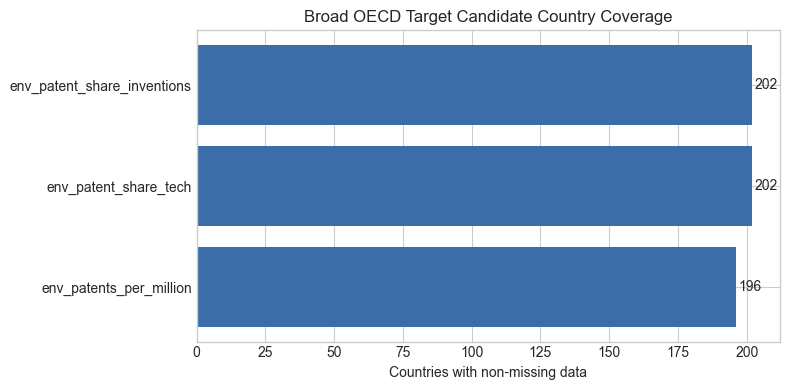

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
target_plot = candidate_overview.sort_values("countries_with_data")
ax.barh(target_plot["variable"], target_plot["countries_with_data"], color="#3B6EA8")
ax.set_title("Broad OECD Target Candidate Country Coverage")
ax.set_xlabel("Countries with non-missing data")
ax.set_ylabel("")
for i, value in enumerate(target_plot["countries_with_data"]):
    ax.text(value + 1, i, str(int(value)), va="center")
plt.tight_layout()


## Technology Domains Below `ENV_PAT`

`ENV_PAT` is the overall environment-related technology total. OECD also exposes broad technology domains that can later support robustness checks or heterogeneity analysis.

The metadata also contains more detailed subdomain codes. In the current `Patents - indicators` dataflow, the available data are the broad domains listed below; the detailed subdomain codes are useful for understanding the taxonomy, but they should be checked before being treated as directly available modeling variables.


In [8]:
tech_summary_display = technology_category_summary.sort_values(
    "metadata_subdomain_count", ascending=False
).reset_index(drop=True)

tech_summary_display[
    [
        "broad_domain_code",
        "broad_domain_label",
        "available_in_indicator_data",
        "metadata_subdomain_count",
        "example_subdomains",
    ]
]


,broad_domain_code,broad_domain_label,available_in_indicator_data,metadata_subdomain_count,example_subdomains
0,ADAPT,Climate change adaptation technologies,True,37,"Adaptation technologies in agriculture, forestry, livestock or agro-alimentary production; In agriculture;..."
1,ENE,"Climate change mitigation technologies related to energy generation, transmission or distribution",True,32,"Combustion technologies with mitigation potential (e.g. using fossil fuels, biomass, waste, etc.); Technol..."
2,GOODS,Climate change mitigation technologies in the production or processing of goods,True,32,"Technologies relating to agriculture, livestock or agroalimentary industries; Afforestation or reforestati..."
3,WAT_WASTE,Climate change mitigation technologies related to wastewater treatment or waste management,True,22,Enabling technologies or technologies with a potential or indirect contribution to GHG emissions mitigatio...
4,MAN,Environmental management,True,16,"Air pollution abatement; Emissions abatement from mobile sources (e.g. NOx, CO, HC, PM emissions from moto..."
5,OCEAN,Sustainable ocean economy,True,13,Climate change adaptation in coastal zones; Desalination of sea water; Climate change mitigation and adapt...
6,TRA,Climate change mitigation technologies related to transportation,True,12,Aeronautics or air transport; Enabling technologies in transport; Application of hydrogen technology to tr...
7,BUILD,Climate change mitigation technologies related to buildings,True,10,Architectural or constructional elements improving the thermal performance of buildings; Enabling technolo...
8,GHG,"Capture, storage, sequestration or disposal of greenhouse gases",True,5,Capture or disposal of methane (CH4); Capture or disposal of carbon dioxide (CO2); Capture or disposal of ...
9,ICT,Climate change mitigation in information and communication technologies (ICT),True,3,Energy efficiency in communication networks; Energy efficient computing; Not elsewhere classified


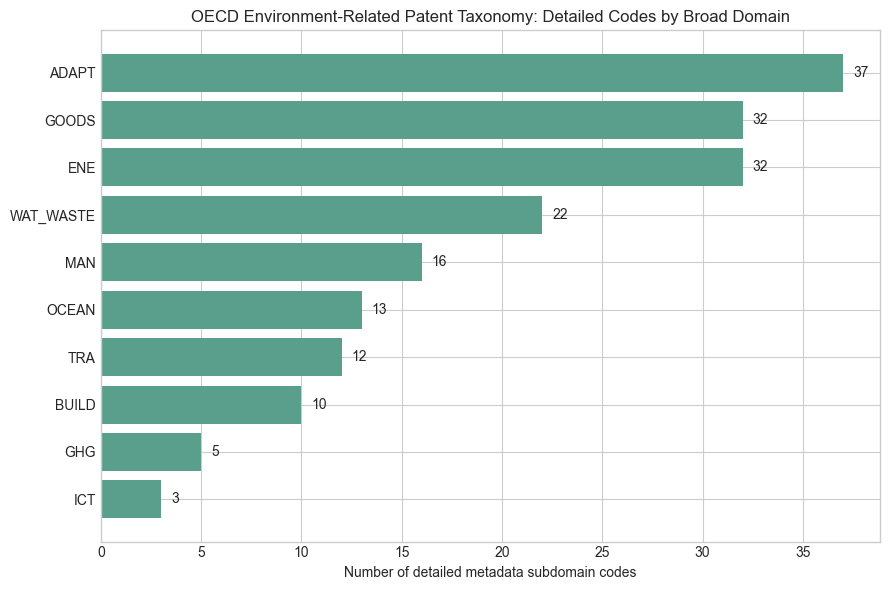

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
tech_plot = tech_summary_display.sort_values("metadata_subdomain_count")
ax.barh(tech_plot["broad_domain_code"], tech_plot["metadata_subdomain_count"], color="#5A9E8C")
ax.set_title("OECD Environment-Related Patent Taxonomy: Detailed Codes by Broad Domain")
ax.set_xlabel("Number of detailed metadata subdomain codes")
ax.set_ylabel("")
for i, value in enumerate(tech_plot["metadata_subdomain_count"]):
    ax.text(value + 0.5, i, str(int(value)), va="center")
plt.tight_layout()


In [10]:
subdomain_examples = (
    technology_domains[
        technology_domains["domain_role"].eq("metadata subdomain under available broad domain")
    ]
    .groupby("broad_domain_code", group_keys=False)
    .head(4)
    .sort_values(["broad_domain_code", "code"])
)

subdomain_examples[["broad_domain_code", "code", "label"]].reset_index(drop=True)


,broad_domain_code,code,label
0,ADAPT,ADAPT_AGR,"Adaptation technologies in agriculture, forestry, livestock or agro-alimentary production"
1,ADAPT,ADAPT_AGR_AGR,In agriculture
2,ADAPT,ADAPT_AGR_ECO,Ecological corridors or buffer zones
3,ADAPT,ADAPT_AGR_FISH,In fisheries management
4,BUILD,BUILD_ARC,Architectural or constructional elements improving the thermal performance of buildings
5,BUILD,BUILD_ENA,Enabling technologies in buildings
6,BUILD,BUILD_ENE,Energy efficiency in buildings
7,BUILD,BUILD_ENE_APP,Energy efficiency in home appliances
8,ENE,ENE_COM,"Combustion technologies with mitigation potential (e.g. using fossil fuels, biomass, waste, etc.)"
9,ENE,ENE_COM_INP,Technologies for improved input efficiency (efficient combustion or heat usage)


## Predictor Coverage

Predictor coverage matters because the final modeling panel will only be as broad as the intersection of target and predictor availability.

A variable can be theoretically attractive but still problematic if it removes too many countries or years.


In [11]:
predictors = summary[~summary["dataset_id"].eq("oecd_patents_environment")].copy()
predictors = predictors.sort_values(["dataset_id", "non_missing_observations"], ascending=[True, False])
predictors[
    [
        "dataset_id",
        "variable",
        "source_variable",
        "non_missing_observations",
        "countries_with_data",
        "first_year",
        "last_year",
    ]
]


,dataset_id,variable,source_variable,non_missing_observations,countries_with_data,first_year,last_year
0,oecd_eps,eps_index,POL_STRINGENCY.EPS,1240,40,1990,2020
10,world_bank_wdi,population,SP.POP.TOTL,7595,217,1990,2024
7,world_bank_wdi,gdp,NY.GDP.MKTP.KD,7096,213,1990,2024
8,world_bank_wdi,gdp_per_capita,NY.GDP.PCAP.KD,7096,213,1990,2024
12,world_bank_wdi,renewable_energy_share,EG.FEC.RNEW.ZS,6746,212,1990,2022
9,world_bank_wdi,manufacturing_share,NV.IND.MANF.ZS,6000,203,1990,2024
4,world_bank_wdi,co2_per_capita,EN.ATM.CO2E.PC,5920,191,1990,2020
6,world_bank_wdi,fossil_energy_share,EG.USE.COMM.FO.ZS,4978,179,1990,2024
5,world_bank_wdi,energy_intensity,EG.EGY.PRIM.PP.KD,4486,201,2000,2022
11,world_bank_wdi,rd_expenditure_gdp,GB.XPD.RSDV.GD.ZS,2467,156,1996,2024


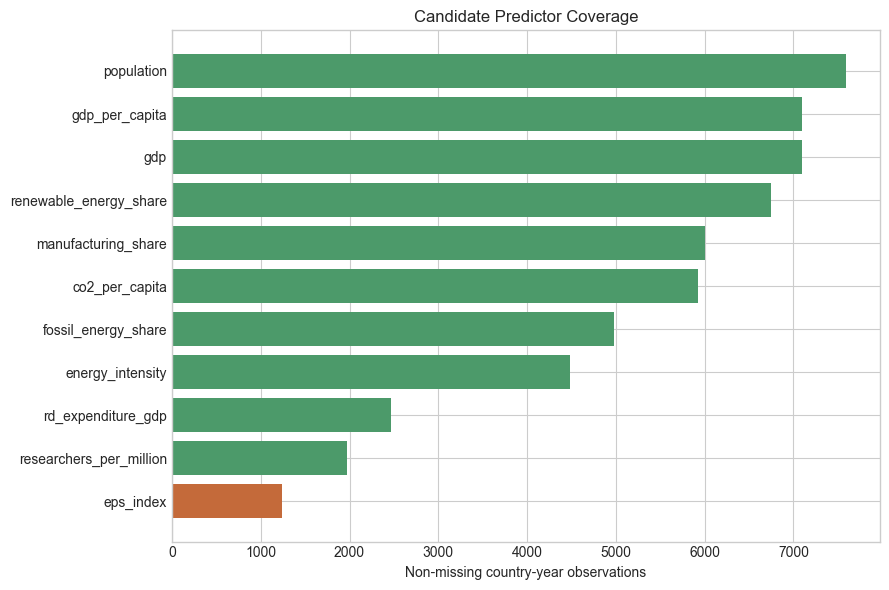

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
predictor_plot = predictors.sort_values("non_missing_observations")
colors = predictor_plot["dataset_id"].map({
    "world_bank_wdi": "#4C9A6A",
    "oecd_eps": "#C46A3A",
}).fillna("#666666")
ax.barh(predictor_plot["variable"], predictor_plot["non_missing_observations"], color=colors)
ax.set_title("Candidate Predictor Coverage")
ax.set_xlabel("Non-missing country-year observations")
ax.set_ylabel("")
plt.tight_layout()


## Year Coverage

The target candidates begin in 1990, but several predictors start later or end earlier. This matters for the eventual lag structure.

A predictor that begins in 1996, for example, cannot support a model that predicts 1991 innovation with a `t-1` lag.


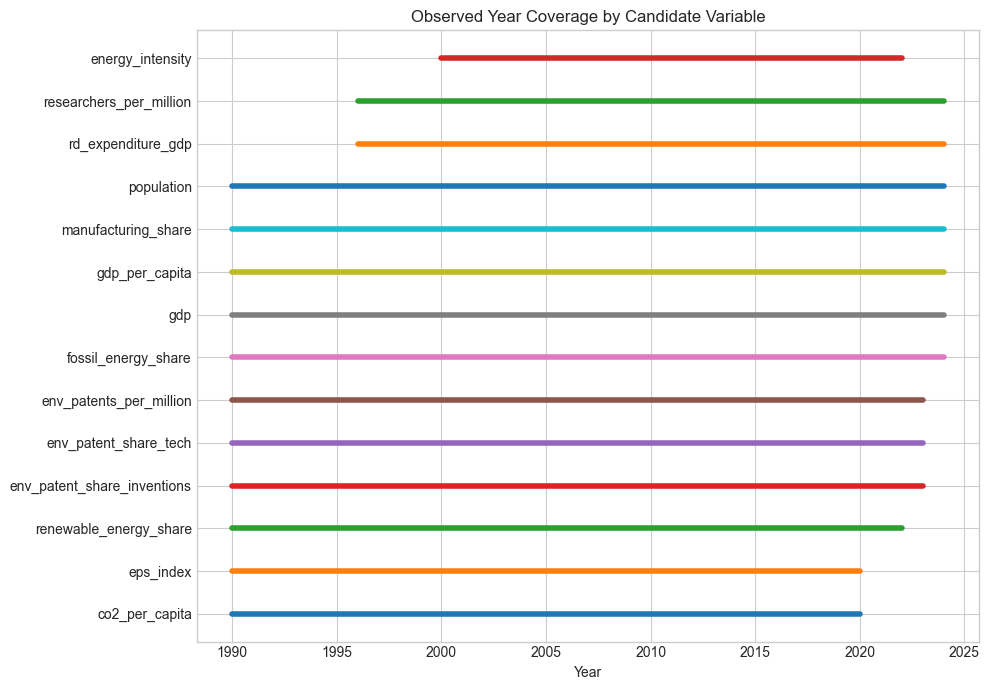

In [13]:
coverage = summary.sort_values(["first_year", "last_year", "variable"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
for y, row in coverage.iterrows():
    ax.plot([row["first_year"], row["last_year"]], [y, y], linewidth=4)

ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage["variable"])
ax.set_title("Observed Year Coverage by Candidate Variable")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()


## Interpretation for the Next Research Step

The data are feasible enough to continue, but the project should not jump to modeling yet.

Recommended next steps:

1. Use the OECD metadata tables above to discuss the target-variable meaning before selecting one main outcome.
2. Decide whether the main target should prioritize portfolio share (`PT_TECH` or `PT_INV`) or innovation intensity (`INV_PS`).
3. Treat `ENV_PAT` as the broad main target domain and the narrower technology domains as later robustness or heterogeneity options.
4. Decide whether the project prioritizes broad country coverage or stronger policy variables.
5. Treat EPS as valuable but sample-restricting.
6. Be cautious with R&D variables because they have strong theoretical value but thinner coverage.
7. Record the final target decision in `0_organization/decision_log.md` only after team discussion.
